In [1]:
from oceanalysis import OceanModel, OceanData, compute
import xarray as xr

In [2]:
model = OceanModel('POP2-LR')
model.grid.ilon

'i'

In [3]:
ds = xr.load_dataset("../model_config/POP2-LR/pop_grid_1deg40.nc")
ds

<xarray.Dataset> Size: 52MB
Dimensions:      (j: 384, i: 320, k: 40, nreg: 14)
Coordinates:
    TLONG        (j, i) float64 983kB 320.6 321.7 322.8 ... 318.9 319.4 319.8
    TLAT         (j, i) float64 983kB -79.22 -79.22 -79.22 ... 72.2 72.19 72.19
    ULONG        (j, i) float64 983kB 321.1 322.3 323.4 ... 319.2 319.6 320.0
    ULAT         (j, i) float64 983kB -78.95 -78.95 -78.95 ... 72.42 72.41 72.41
  * nreg         (nreg) int64 112B 0 1 2 3 4 5 6 7 8 9 10 11 12 13
  * k            (k) float64 320B 5.006 15.07 25.28 ... 5.125e+03 5.375e+03
  * j            (j) int64 3kB 0 1 2 3 4 5 6 7 ... 377 378 379 380 381 382 383
  * i            (i) int64 3kB 0 1 2 3 4 5 6 7 ... 313 314 315 316 317 318 319
Data variables: (12/14)
    TAREA        (j, i) float64 983kB 1.125e+13 1.125e+13 ... 7.432e+12
    UAREA        (j, i) float64 983kB 1.125e+13 1.125e+13 ... 7.432e+12
    DXT          (j, i) float64 983kB 1.894e+06 1.893e+06 ... 1.473e+06
    DYT          (j, i) float64 983kB 5.94e+06 5.94e+06 ... 5.046e+06 5.046e+06
    DXU          (j, i) float64 983kB 2.397e+06 2.397e+06 ... 1.391e+06
    DYU          (j, i) float64 983kB 5.94e+06 5.94e+06 ... 5.493e+06 5.493e+06
    ...           ...
    KMT          (j, i) int64 983kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    REGION_MASK  (j, i) int32 492kB 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0
    region_name  (nreg) <U21 1kB 'Caspian Sea' 'Black Sea' ... 'Hudson Bay'
    region_val   (nreg) int64 112B -14 -13 -12 -5 1 2 3 4 6 7 8 9 10 11
    topo_mask3D  (k, j, i) float64 39MB nan nan nan nan nan ... nan nan nan nan
    bathymetry   (j, i) float64 983kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    lateral_dims:   [384 320]
    vertical_dims:  40
    title:          POP_gx1v6 grid 40 z-levels

In [4]:
path = "../../../mpop/data/edgetrP1/tavg/t.edgetrP1_it001_b2.000002.nc"
test_data = xr.load_dataset(path)

In [5]:
data = OceanData(path, 'POP2.yml')

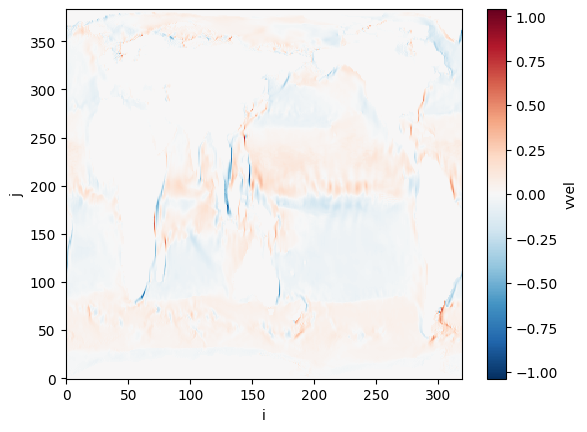

In [6]:
data.vvel.isel(k=0).plot()

In [8]:
sfc = compute.streamfunction(model, data)

(40, 384, 320)
('k', 'j', 'i')
('j', 'i')


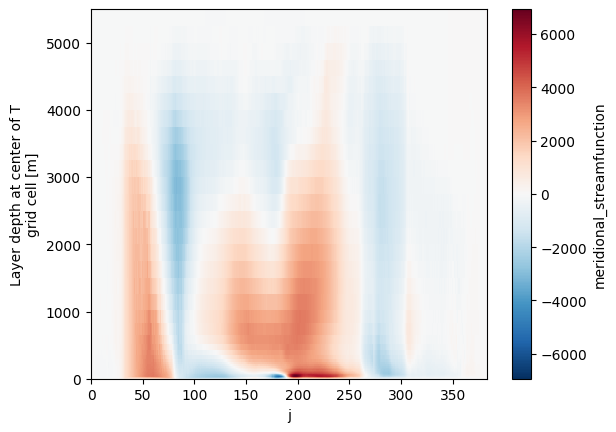

In [9]:
sfc.plot()

In [10]:
sfc

<xarray.DataArray 'meridional_streamfunction' (k: 40, j: 384)> Size: 123kB
array([[ 0.        ,  0.        ,  1.29253605, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -1.68971746, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -3.72130277, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        , -0.01234653, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -0.01234653, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -0.01234653, ...,  0.        ,
         0.        ,  0.        ]], shape=(40, 384))
Coordinates:
  * j        (j) int64 3kB 0 1 2 3 4 5 6 7 8 ... 376 377 378 379 380 381 382 383
  * k        (k) float64 320B 5.006 15.07 25.28 ... 5.125e+03 5.375e+03

In [11]:
model.grid.udx

<xarray.DataArray 'DXU' (j: 384, i: 320)> Size: 983kB
array([[2396630.14446974, 2396630.14446974, 2396630.14446974, ...,
        2396630.14446974, 2396630.14446974, 2396630.14446974],
       [2510985.98870535, 2510985.98870535, 2510985.98870535, ...,
        2510985.98870535, 2510985.98870535, 2510985.98870535],
       [2625123.52541615, 2625123.52541615, 2625123.52541615, ...,
        2625123.52541615, 2625123.52541615, 2625123.52541615],
       ...,
       [1714673.76651229, 1713860.79472732, 1712495.20914674, ...,
        1713860.79472732, 1714673.76651229, 1714939.8761523 ],
       [1554838.13362422, 1554069.67936816, 1552779.42960208, ...,
        1554069.67936816, 1554838.13362422, 1555089.87399024],
       [1390583.0833508 , 1389865.97173196, 1388662.44323673, ...,
        1389865.97173196, 1390583.0833508 , 1390818.1902271 ]],
      shape=(384, 320))
Coordinates:
    TLONG    (j, i) float64 983kB 320.6 321.7 322.8 323.9 ... 318.9 319.4 319.8
    TLAT     (j, i) float64 983kB -79.22 -79.22 -79.22 ... 72.2 72.19 72.19
    ULONG    (j, i) float64 983kB 321.1 322.3 323.4 324.5 ... 319.2 319.6 320.0
    ULAT     (j, i) float64 983kB -78.95 -78.95 -78.95 ... 72.42 72.41 72.41
  * j        (j) int64 3kB 0 1 2 3 4 5 6 7 8 ... 376 377 378 379 380 381 382 383
  * i        (i) int64 3kB 0 1 2 3 4 5 6 7 8 ... 312 313 314 315 316 317 318 319
Attributes:
    units:      cm
    long_name:  x-spacing centered at U points